In [1]:
from google.colab import files
uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]


Saving thẻ.jpg to thẻ.jpg


## Bước 1: Ảnh màu → Ảnh xám

**Công thức:** `xam = 0.299*R + 0.587*G + 0.114*B`


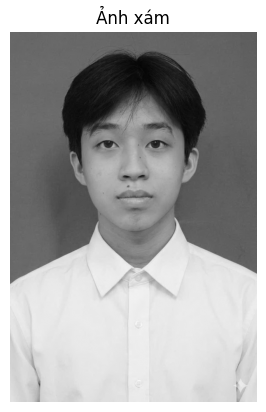

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = np.array(Image.open(IMAGE_PATH).convert("RGB"))
H, W = img.shape[0], img.shape[1]

gray = np.zeros((H, W), dtype=np.uint8)

for y in range(H):
    for x in range(W):
        R, G, B = img[y, x, 0], img[y, x, 1], img[y, x, 2]
        gray[y, x] = round(0.299*R + 0.587*G + 0.114*B)

plt.imshow(gray, cmap="gray")
plt.title("Ảnh xám")
plt.axis("off")
plt.show()


## Bước 2: Tính Histogram H1

**Công thức:** `H[muc_sang] += 1` cho mỗi pixel

(đếm xem mỗi mức sáng 0-255 xuất hiện bao nhiêu lần)


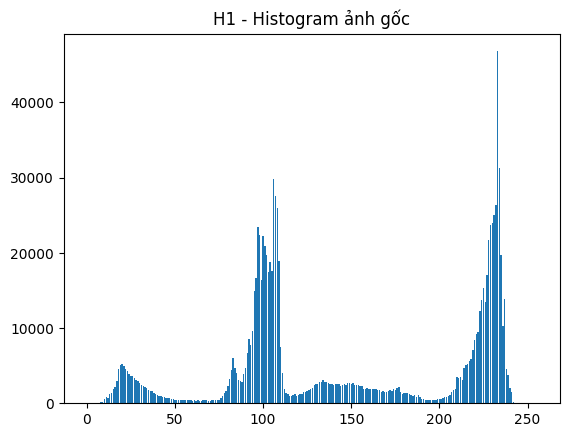

In [3]:
H1 = [0] * 256

for y in range(H):
    for x in range(W):
        H1[gray[y, x]] += 1

plt.bar(range(256), H1)
plt.title("H1 - Histogram ảnh gốc")
plt.show()


## Bước 3: Cân bằng Histogram

**Công thức (3 dòng):**
```
CDF[k]  = H1[0] + H1[1] + ... + H1[k]      (cộng dồn)
moi[k]  = round( CDF[k] / (H*W) * 255 )    (chuẩn hóa về 0-255)
anh_moi[y,x] = moi[ gray[y,x] ]            (áp dụng cho từng pixel)
```


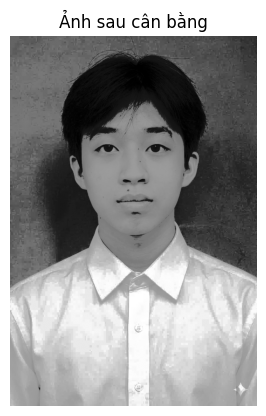

In [4]:
CDF = [0] * 256
tong = 0
for k in range(256):
    tong += H1[k]
    CDF[k] = tong

moi = [0] * 256
for k in range(256):
    moi[k] = round(CDF[k] / (H * W) * 255)

eq_img = np.zeros((H, W), dtype=np.uint8)
for y in range(H):
    for x in range(W):
        eq_img[y, x] = moi[gray[y, x]]

plt.imshow(eq_img, cmap="gray")
plt.title("Ảnh sau cân bằng")
plt.axis("off")
plt.show()


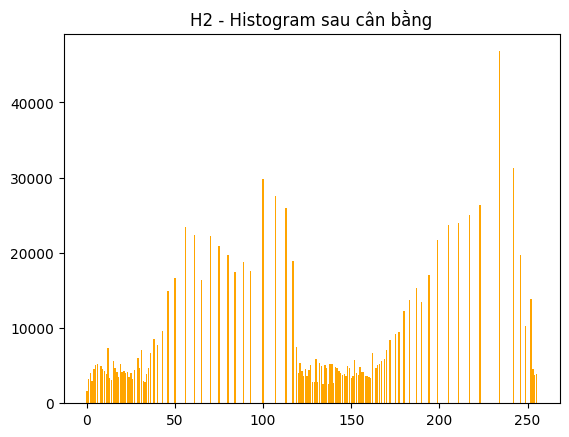

In [5]:
H2 = [0] * 256
for y in range(H):
    for x in range(W):
        H2[eq_img[y, x]] += 1

plt.bar(range(256), H2, color="orange")
plt.title("H2 - Histogram sau cân bằng")
plt.show()


## Bước 4: Thu hẹp Histogram về [a, b]

**Công thức:** `k_moi = round( a + (b-a)/255 * k )`


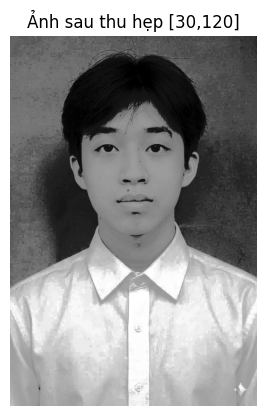

In [6]:
a, b = 30, 120

shrunk_img = np.zeros((H, W), dtype=np.uint8)

for y in range(H):
    for x in range(W):
        k = eq_img[y, x]
        shrunk_img[y, x] = round(a + (b - a) / 255 * k)

plt.imshow(shrunk_img, cmap="gray")
plt.title(f"Ảnh sau thu hẹp [{a},{b}]")
plt.axis("off")
plt.show()


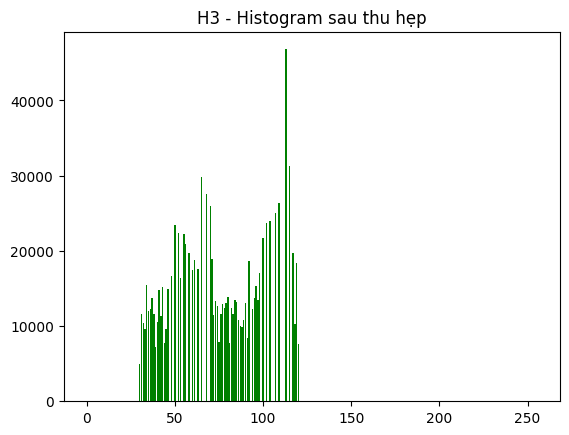

In [7]:
H3 = [0] * 256
for y in range(H):
    for x in range(W):
        H3[shrunk_img[y, x]] += 1

plt.bar(range(256), H3, color="green")
plt.title("H3 - Histogram sau thu hẹp")
plt.show()


## Bước 5: Hiển thị tổng hợp & lưu kết quả

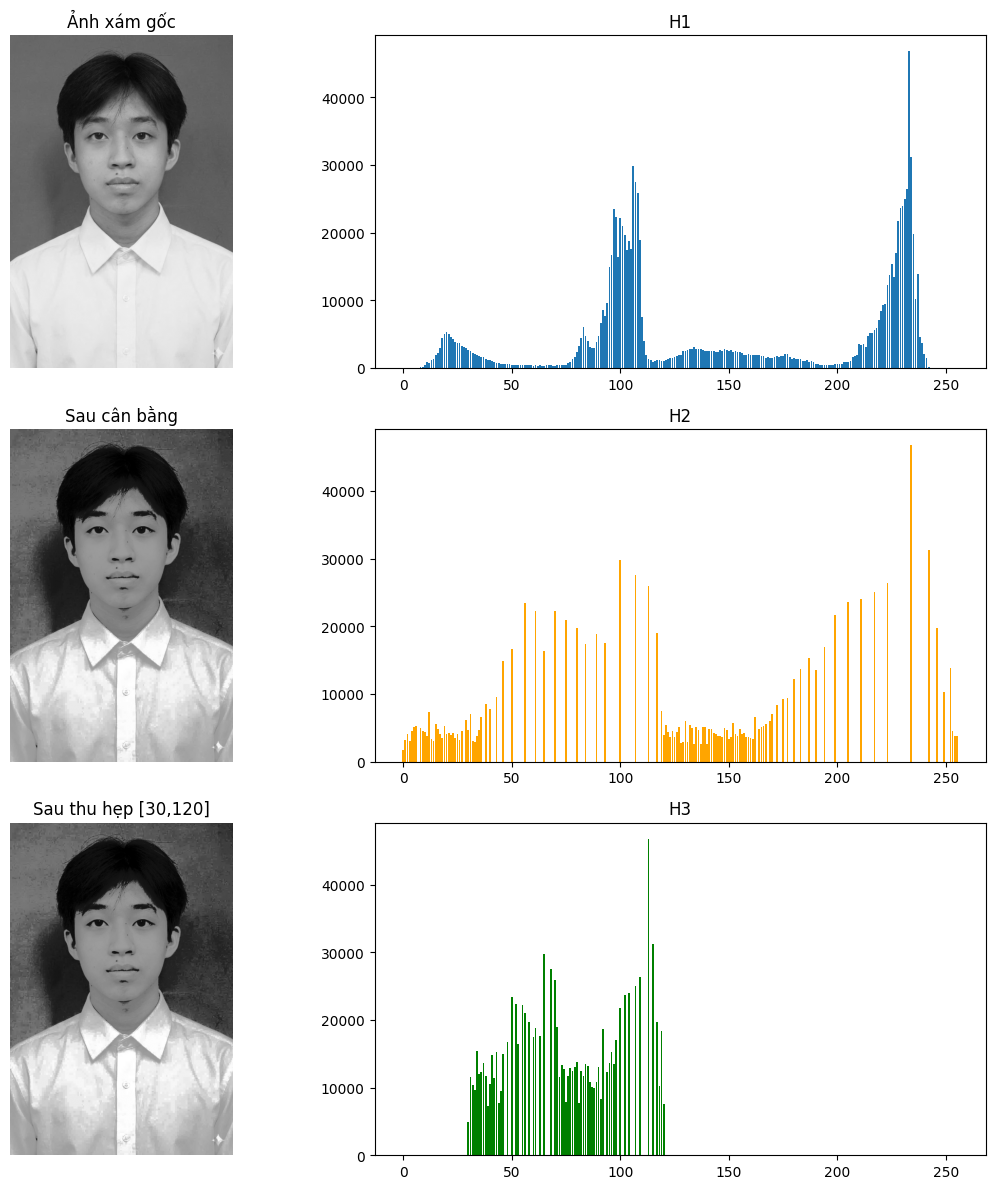

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

axes[0,0].imshow(gray, cmap="gray");        axes[0,0].set_title("Ảnh xám gốc");        axes[0,0].axis("off")
axes[0,1].bar(range(256), H1);              axes[0,1].set_title("H1")

axes[1,0].imshow(eq_img, cmap="gray");      axes[1,0].set_title("Sau cân bằng");       axes[1,0].axis("off")
axes[1,1].bar(range(256), H2, color="orange"); axes[1,1].set_title("H2")

axes[2,0].imshow(shrunk_img, cmap="gray");  axes[2,0].set_title(f"Sau thu hẹp [{a},{b}]"); axes[2,0].axis("off")
axes[2,1].bar(range(256), H3, color="green");  axes[2,1].set_title("H3")

plt.tight_layout()
plt.savefig("cau1_ket_qua.png", dpi=150)
plt.show()


In [ ]:
from google.colab import files
files.download("cau1_ket_qua.png")
